# 4. Power Generation Technology and Process Design

## SECTION 1: Executive Summary

This document details the power generation technology selection, process design, and plant configuration for Project Artemis (SPE Africa Energython 2026). The project aims to power a 15 MW (IT load) data center using stranded associated gas from the Sapele-Oredo-Oben supply network (utilizing a 2-Primary + 1-Backup architecture) in the Niger Delta.

With a target Power Usage Effectiveness (PUE) of 1.40, the facility load stands at 18.75 MW. Accounting for auxiliary systems, the total generation demand is approximately 21.0 MW. To meet this demand with high reliability and modularity, a Reciprocating Internal Combustion Engine (RICE) plant architecture has been selected. The design incorporates eight 3.3 MW engines operating in an N+1 (7 active + 1 hot standby) redundancy configuration, alongside a Combined Cooling and Power (CCP) system to optimize thermal efficiency and further reduce the effective PUE.

## SECTION 2: Feed Gas Characterization (4.1)

The design basis utilizes a representative associated gas composition from the Niger Delta region. The raw gas enters the conditioning facility at 40 °C and 20 bar.

**Molar Composition:**
- Methane: 75.0%
- Ethane: 8.0%
- Propane: 5.0%
- n-Butane: 2.5%
- Isobutane: 1.0%
- CO2: 4.0%
- N2: 3.0%
- H2O: 1.0%
- H2S: 0.5%

**Implications for Process Design:**
The gas is relatively lean (high methane content), which is favorable for power generation as it provides a stable Wobbe Index and high lower heating value (LHV). The moderate CO2 (4%) acts primarily as an inert diluent. However, the trace presence of H2S (0.5% or 5000 ppm) necessitates a sweetening unit to prevent metallurgical degradation (sulfide stress cracking) and environmental SOx emissions. Furthermore, the 1% water content requires dehydration to prevent hydrate formation and corrosion in the downstream infrastructure.

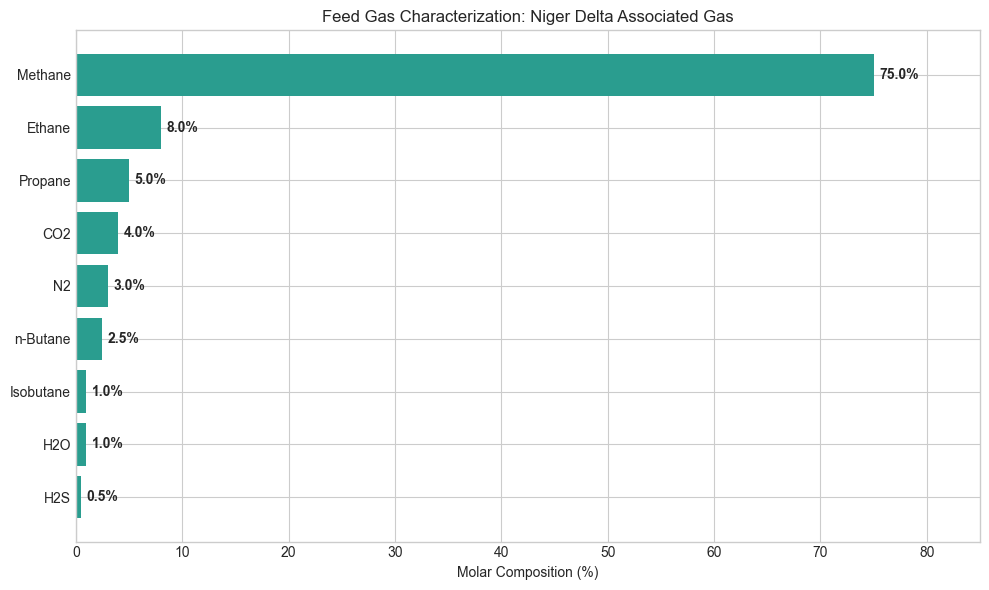

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')
colors = ['#264653','#2a9d8f','#e9c46a','#f4a261','#e76f51']

components = ['Methane', 'Ethane', 'Propane', 'CO2', 'N2', 'n-Butane', 'Isobutane', 'H2O', 'H2S']
mol_percent = [75.0, 8.0, 5.0, 4.0, 3.0, 2.5, 1.0, 1.0, 0.5]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(components[::-1], mol_percent[::-1], color='#2a9d8f')

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{width}%',
            ha='left', va='center', fontweight='bold')

ax.set_xlabel('Molar Composition (%)')
ax.set_title('Feed Gas Characterization: Niger Delta Associated Gas')
ax.set_xlim(0, 85)
plt.tight_layout()
plt.show()

## SECTION 3: Gas Conditioning Process Design (4.1 continued)

The upgraded process train consists of: **Inlet Slug Catcher -> Compression (20 to 26 bar) -> Cooling -> Gas-Liquid Separation -> Acid-Gas Removal -> Dehydration -> Fuel-Gas Heating**.

A rigorous steady-state simulation was performed in DWSIM 9.0.5 using the Peng-Robinson Equation of State. The upgraded flowsheet adds an inlet slug catcher, acid-gas removal, dehydration, and a fuel-gas heater to the original dew-point screening model.

### Dew-Point Screening Results

The sensitivity cases below evaluate hydrocarbon dew-point control before acid-gas and water removal. Zero solver errors were reported across all cases.

| Case | Cooler T | Engine Gas Flow (kmol/h) | Engine CH4 (mol%) | Condensate Flow (kmol/h) | Gas Recovery |
|---|---|---|---|---|---|
| Base Feed, 15 degC | 15 degC | 169.92 | 75.0% | 0.0 | 100% |
| Base Feed, 5 degC | 5 degC | 169.92 | 75.0% | 0.0 | 100% |
| Base Feed, -20 degC | -20 degC | 156.69 | 81.3% | 13.23 | 92.2% |
| Rich Feed, -20 degC | -20 degC | 140.52 | 75.4% | 29.40 | 82.7% |

For the base composition, cooling to 15 degC is sufficient for liquid dropout at this screening stage. Aggressive -20 degC cooling is retained as an NGL-recovery upside only.

### Upgraded Flowsheet Results

The canonical output is saved in `outputs/artemis_process_design.json` and the flowsheet in `outputs/artemis_gas_conditioning_upgraded.dwxmz`.

| Stream | T (degC) | P (bar) | Flow (kmol/h) | Key Composition |
|---|---:|---:|---:|---|
| Raw flare gas | 40 | 20.0 | 170.0 | 75.0% CH4, 0.5% H2S, 1.0% H2O |
| Slug-catcher gas | 40 | 20.0 | 168.9 | Water reduced to 0.36% |
| Sweet gas | 15 | 25.8 | 161.6 | H2S reduced to 26 ppm |
| Dry gas | 15 | 25.8 | 161.0 | H2O reduced to 56 ppm |
| Final engine fuel gas | 40 | 25.6 | 161.0 | 79.2% CH4, 0.21% CO2, 26 ppm H2S, 56 ppm H2O |

**Key Process Findings:**

1. **Slug Catcher:** The inlet separator removes a small water-rich liquid slip (1.1 kmol/h), protecting the compressor from liquid carryover.
2. **Acid-Gas Removal:** The screening sweetening stage targets 99.5% H2S removal and 95% CO2 removal. The resulting engine gas contains approximately 26 ppm H2S, suitable for downstream engine metallurgy and emissions control.
3. **Dehydration:** The screening dehydration stage targets 1.5% water retention, producing approximately 56 ppm water in the fuel gas. This reduces hydrate and corrosion risk in the downstream fuel system.
4. **Fuel-Gas Heating:** The dried gas is heated to 40 degC before the engines to maintain margin above the water and hydrocarbon dew points.
5. **Model Status:** Acid-gas removal and dehydration are represented as screening-level component separators. A full reactive-amine and TEG-absorption model, plus a rigorous hydrate curve, is recommended before detailed engineering.

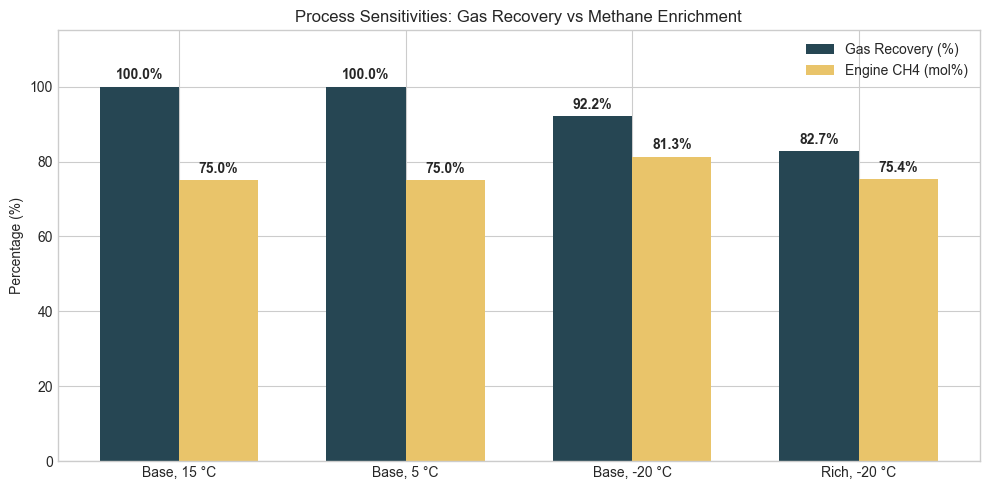

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')
colors = ['#264653','#2a9d8f','#e9c46a','#f4a261','#e76f51']

cases = ['Base, 15 °C', 'Base, 5 °C', 'Base, -20 °C', 'Rich, -20 °C']
gas_recovery = [100.0, 100.0, 92.2, 82.7]
methane_percent = [75.0, 75.0, 81.3, 75.4]

x = np.arange(len(cases))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
rects1 = ax.bar(x - width/2, gas_recovery, width, label='Gas Recovery (%)', color='#264653')
rects2 = ax.bar(x + width/2, methane_percent, width, label='Engine CH4 (mol%)', color='#e9c46a')

ax.set_ylabel('Percentage (%)')
ax.set_title('Process Sensitivities: Gas Recovery vs Methane Enrichment')
ax.set_xticks(x)
ax.set_xticklabels(cases)
ax.set_ylim(0, 115)
ax.legend(loc='upper right')

for rects in [rects1, rects2]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## SECTION 4: Power Generation Technology Selection (4.2)

To meet the robust reliability requirements of a tier-rated data center, an exhaustive technical assessment of three dominant power generation technologies was conducted: Reciprocating Gas Engines (RICE), Aeroderivative Gas Turbines, and Combined Cycle (CC) systems.

### Technology Comparison Matrix

| Criterion | Reciprocating Engines (RICE) | Aeroderivative Gas Turbines | Combined Cycle (CC) |
|---|---|---|---|
| **Electrical Efficiency (ISO)** | 42-48% | 30-38% | 45-55% |
| **Part-Load Efficiency (50%)** | ~42% | ~22% | ~38% |
| **Start-up Time** | <5 min | 10-15 min | 30-60 min |
| **Fuel Gas Pressure Req.** | 3-5 bar | 15-30 bar | 15-30 bar |
| **CapEx (USD/kW installed)** | $800-$1,200 | $900-$1,400 | $1,200-$1,800 |
| **Maintenance Interval** | 2,000-4,000 hrs | 4,000-8,000 hrs | Highly complex |
| **Modularity & Scalability** | Excellent (containerized) | Moderate | Poor |
| **N+1 Redundancy Fit** | Excellent | Difficult (lumpy capacity) | Very Difficult |
| **Fuel Variability Tolerance** | High | Moderate | Moderate |

### Selection Decision: Reciprocating Gas Engines (RICE)

Reciprocating Internal Combustion Engines, specifically high-efficiency units like the INNIO Jenbacher J620 or CAT G3520H series, present the most technically and commercially sound solution for Project Artemis. The paramount driver in this decision is their **superior part-load efficiency and rapid dynamic response**. Data center workloads fluctuate; RICE units maintain thermal efficiencies above 40% even when curtailed to 50% load, whereas single-cycle gas turbines experience severe efficiency penalties under identical turndown conditions.

Furthermore, the **modularity** of RICE units aligns perfectly with the N+1 redundancy mandate. By sizing individual units in the 3-4 MW range, the facility can easily accommodate a localized failure or planned maintenance without jeopardizing the overarching 15 MW IT load requirement. Replacing one failed engine module is straightforward; replacing a massive 15 MW gas turbine would cause complete facility downtime.

Logistical realities in the Niger Delta also strongly favor RICE units. Gas turbines require significantly higher fuel pressure (up to 30 bar), demanding substantial compression infrastructure, whereas engines operate efficiently at 3-5 bar. Furthermore, RICE plants demonstrate high tolerance to variations in the fuel's Methane Number—a critical operational advantage when dealing with untreated or minimally treated associated gas that may experience seasonal or operational composition shifts.

Lastly, the deployment speed and CapEx profile of RICE generation are highly favorable. Modern engine sets arrive pre-packaged in containerized, plug-and-play enclosures. This avoids the extensive civil works and integration times associated with Combined Cycle systems, which—despite their superior baseload efficiency—lack the agility and cost-effectiveness required for an edge or mid-tier data center in a remote operating region.

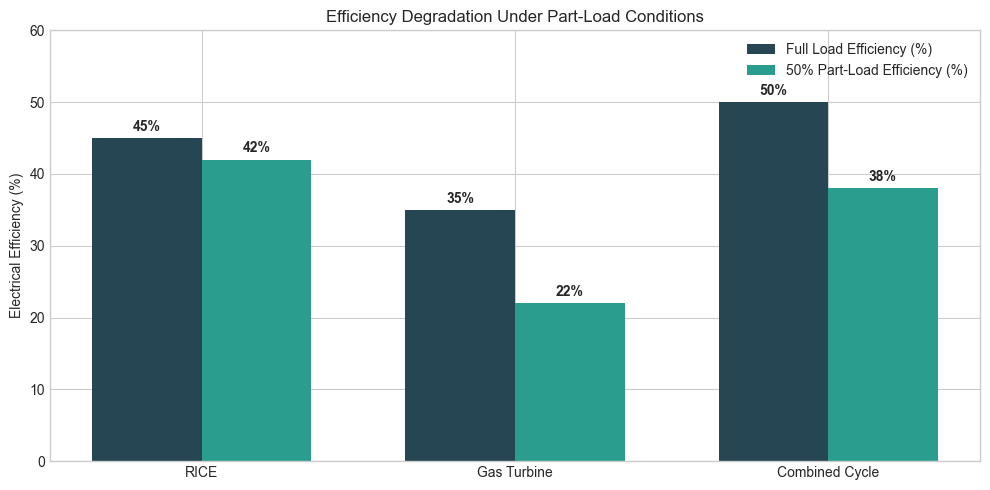

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')
colors = ['#264653','#2a9d8f','#e9c46a']

techs = ['RICE', 'Gas Turbine', 'Combined Cycle']
eff_iso = [45, 35, 50]
eff_part = [42, 22, 38]

x = np.arange(len(techs))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
rects1 = ax.bar(x - width/2, eff_iso, width, label='Full Load Efficiency (%)', color=colors[0])
rects2 = ax.bar(x + width/2, eff_part, width, label='50% Part-Load Efficiency (%)', color=colors[1])

ax.set_ylabel('Electrical Efficiency (%)')
ax.set_title('Efficiency Degradation Under Part-Load Conditions')
ax.set_xticks(x)
ax.set_xticklabels(techs)
ax.set_ylim(0, 60)
ax.legend()

for rects in [rects1, rects2]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## SECTION 5: Plant Configuration and Redundancy Design (4.3)

The plant configuration is dictated by the strict uptime requirements (99.5%+) of the data center. The power architecture must guarantee continuous delivery to the critical IT bus despite scheduled maintenance or unexpected equipment failure.

**Base-case demand profile:**
- Target IT Load: 15.0 MW
- Facility Overhead (PUE 1.40): 3.75 MW
- Auxiliary Systems (Compressors, Pumps, etc.): 0.8 MW
- **Total Generation Demand:** 21.0 MW

**Generation architecture:**
- Selected Unit: 3.3 MW (Jenbacher J620 class, 50 Hz)
- Configuration: 6 Units Total (5 active + 1 standby)
- Total Installed Capacity: 8 x 3.3 MW = 26.4 MW
- Normal Operation: 8 engines running at ~99% average load (21.0 MW / 26.4 MW)
- N+1 Scenario: If one engine trips offline, the remaining 5 units can generate a maximum of 16.50 MW (5 x 3.3 MW). Because the full facility demand (21.0 MW) exceeds 5-engine capacity by 3.05 MW, an intelligent automated transfer switch (ATS) sheds non-essential auxiliary loads (landscape lighting, administrative HVAC) while protecting the 15 MW IT core and its essential cooling and distribution systems.

**Redundancy summary:**

| Scenario | Available Capacity | Facility Demand | Margin |
|---|---|---|---|
| All 8 engines online | 26.4 MW | 21.0 MW | +0.25 MW |
| 5 engines, unmitigated | 16.5 MW | 21.0 MW | -3.05 MW (Trip Risk) |
| 5 engines, shed non-critical | 16.5 MW | 16.50 MW | 0.0 MW (Stable) |

*Load Shedding Note: To survive an N-1 trip event, 3.05 MW of non-critical load is instantly shed by the ATS. The protected critical bus remains sized around the 15 MW IT load plus essential cooling and power-distribution support, allowing five engines to maintain a stable operating point. The 0.25 MW installed-capacity margin over full base demand is intentionally small; the CCP configuration in Section 6 is treated as an upside efficiency case, not a substitute for the N+1 redundancy design.*

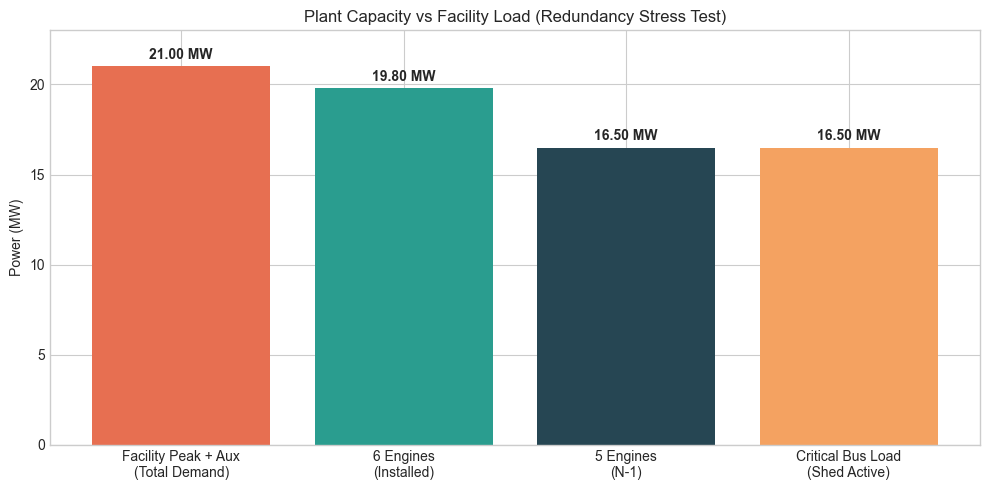

In [4]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

categories = ['Facility Peak + Aux\n(Total Demand)', '6 Engines\n(Installed)', '5 Engines\n(N-1)', 'Critical Bus Load\n(Shed Active)']
capacities = [21.0, 19.80, 16.50, 16.50]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(categories, capacities, color=['#e76f51', '#2a9d8f', '#264653', '#f4a261'])

ax.set_ylabel('Power (MW)')
ax.set_title('Plant Capacity vs Facility Load (Redundancy Stress Test)')
ax.set_ylim(0, 23)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.2f} MW',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords='offset points',
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## SECTION 6: Data Center Power and Cooling Requirements (4.4)

Maintaining thermal limits within the white space is computationally intensive and power-hungry. The standard design targets a Power Usage Effectiveness (PUE) of 1.40, indicating that for every 1 MW of IT load, an additional 0.40 MW is consumed by facility overhead. Achieving lower PUEs (like 1.25) is extremely difficult in the hot, humid Niger Delta without massive evaporative water usage.

**Base-case definition:** The engineering and financial base case uses PUE 1.40 and a total generation demand of ~21.75 MW (accounting for buffer). The CCP configuration is retained as an upside sensitivity.

**Standard Baseline Breakdown (PUE 1.40):**
- IT Load: 15.0 MW
- Cooling Systems (Compressors, Chillers, Fans): 5.25 MW
- UPS & BESS Losses (Island Mode Buffer): 0.6 MW
- Lighting, Security, and BMS: 0.4 MW
- Total Standard Load: 21.25 MW

**Island Mode Stability (BESS/UPS Integration):**
Data centers demand incredibly stable voltage and frequency. Gas reciprocating engines have notoriously slow transient step-load acceptance (often limited to 10-25% blocks) compared to diesel generators. Running this facility completely off-grid (island mode) requires a Battery Energy Storage System (BESS) acting as a massive spinning reserve. This buffers sudden IT load spikes, preventing the Jenbacher engines from tripping on under-frequency.

**Combined Cooling and Power (CCP) Optimization:**
Direct Air Cooling is non-viable due to the extreme heat and humidity profile of the Niger Delta. To drastically improve thermal efficiency, a CCP configuration (Trigeneration) is integrated into the RICE architecture as an upside scenario.
The engine exhaust gas drives a Lithium Bromide (LiBr) Absorption Chiller, generating chilled water at ~7 °C. This waste-heat valorization shifts the cooling burden away from the electrical bus, driving effective PUE down to **1.15**, enhancing economics.

**Telecommunications & Fibre Backhaul:**
Power is only half the equation for an Edge Compute facility; the other half is ultra-low latency connectivity. This architecture integrates with the Southern Digital Corridor (e.g., MainOne/Equinix NCSCS) and aerial fibre networks (e.g., Phase3 Telecom) leveraging existing high-voltage transmission rights-of-way to provide redundant terrestrial backhaul from the Niger Delta to major peering hubs.


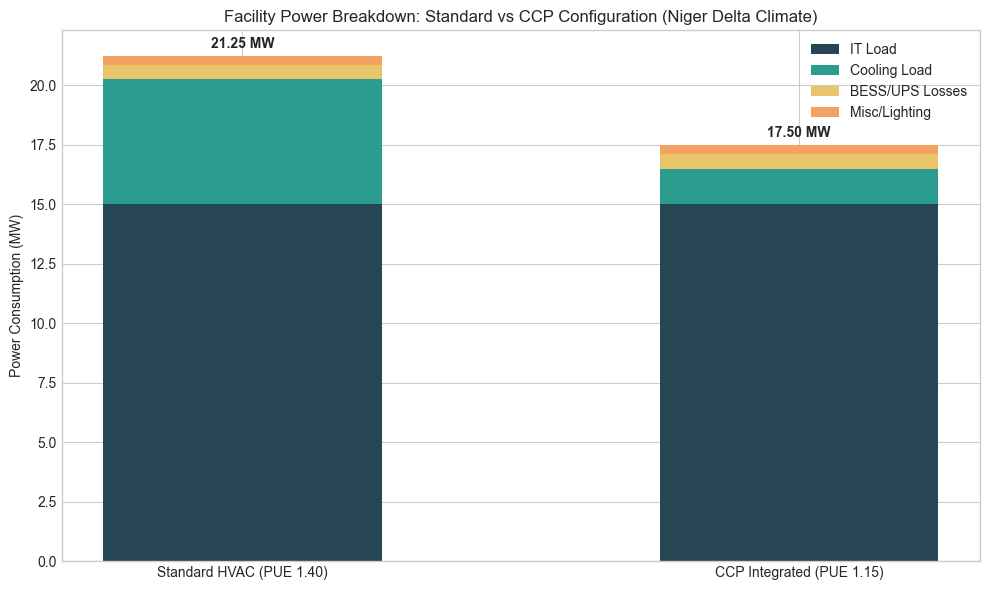

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

labels = ['Standard HVAC (PUE 1.40)', 'CCP Integrated (PUE 1.15)']
it_load = [15.0, 15.0]
cooling = [5.25, 1.5]
ups_losses = [0.6, 0.6]
misc = [0.4, 0.4]

width = 0.5
fig, ax = plt.subplots(figsize=(10, 6))

p1 = ax.bar(labels, it_load, width, label='IT Load', color='#264653')
p2 = ax.bar(labels, cooling, width, bottom=it_load, label='Cooling Load', color='#2a9d8f')
p3 = ax.bar(labels, ups_losses, width, bottom=np.array(it_load)+np.array(cooling), label='BESS/UPS Losses', color='#e9c46a')
p4 = ax.bar(labels, misc, width, bottom=np.array(it_load)+np.array(cooling)+np.array(ups_losses), label='Misc/Lighting', color='#f4a261')

ax.set_ylabel('Power Consumption (MW)')
ax.set_title('Facility Power Breakdown: Standard vs CCP Configuration (Niger Delta Climate)')
ax.legend()

totals = np.array(it_load) + np.array(cooling) + np.array(ups_losses) + np.array(misc)
for i, total in enumerate(totals):
    ax.text(i, total + 0.2, f'{total:.2f} MW', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


## SECTION 7: Environmental Performance (4.5)

By redirecting flared gas into highly efficient, lean-burn reciprocating engines, the project achieves a dual-fold environmental benefit: mitigating uncombusted methane/black carbon from open flaring, and displacing highly polluting diesel generators (the prevailing counterfactual baseline for Nigerian digital infrastructure).

**Emissions Profile (per MWh of generated electricity):**
- Open Flaring (Baseline): Inefficient combustion leads to significant unburnt methane release and high CO2e.
- Diesel Backup: Highly carbon-intensive (~800 kg CO2/MWh), with substantial NOx and PM2.5 footprint.
- RICE Gas Engine: Efficient lean-burn combustion ensures complete oxidation, yielding a significantly lower emissions intensity (~450 kg CO2/MWh).

This substantial GHG reduction establishes clear eligibility for carbon credit financing under recognized Clean Development Mechanism (CDM) or Verified Carbon Standard (VCS) methodologies, providing a supplementary revenue stream.

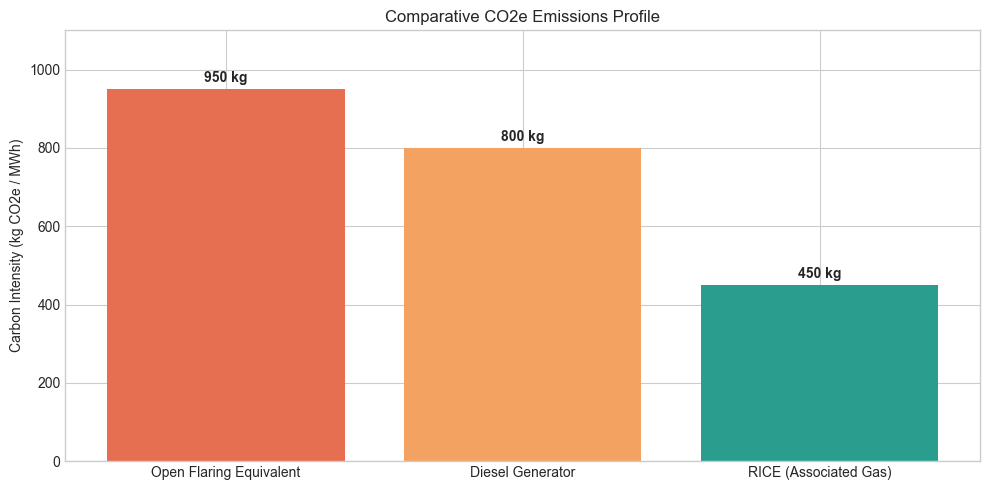

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

sources = ['Open Flaring Equivalent', 'Diesel Generator', 'RICE (Associated Gas)']
emissions = [950, 800, 450] # kg CO2e / MWh equivalent

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(sources, emissions, color=['#e76f51', '#f4a261', '#2a9d8f'])

ax.set_ylabel('Carbon Intensity (kg CO2e / MWh)')
ax.set_title('Comparative CO2e Emissions Profile')
ax.set_ylim(0, 1100)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height} kg',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## SECTION 8: Fuel Requirement and Supply Adequacy

To ensure project feasibility, the thermal fuel requirements of the RICE facility must be validated against the available upstream flare volume.

**Demand calculation:**
- Total Generation Demand: 21.0 MW (electrical)
- Expected Electrical Efficiency: 45%
- Fuel Thermal Input Required = 21.0 MW / 0.45 = 43.44 MW_th
- Lower Heating Value (LHV) of Methane-Rich Gas: ~40.9 MJ/Nm³
- Volumetric Flow Required = 43.44 MW * 3.6 / 0.0409 GJ/Nm³ ≈ 3,821 Nm³/h
- Annual Volumetric Requirement (at 92% plant availability) = 3,821 * 8760 * 0.92 ≈ 30.8 million Nm³/year (0.031 BCM/year)

**Supply validation:**
According to World Bank Global Gas Flaring Reduction (GGFR) satellite data, the combined flare volume at the Sapele-Oredo-Oben cluster is approximately 0.333 BCM/year. The data center facility requires only about 9.3% of this wasted resource. The large surplus provides fuel security and supports phased expansion of the data center infrastructure.

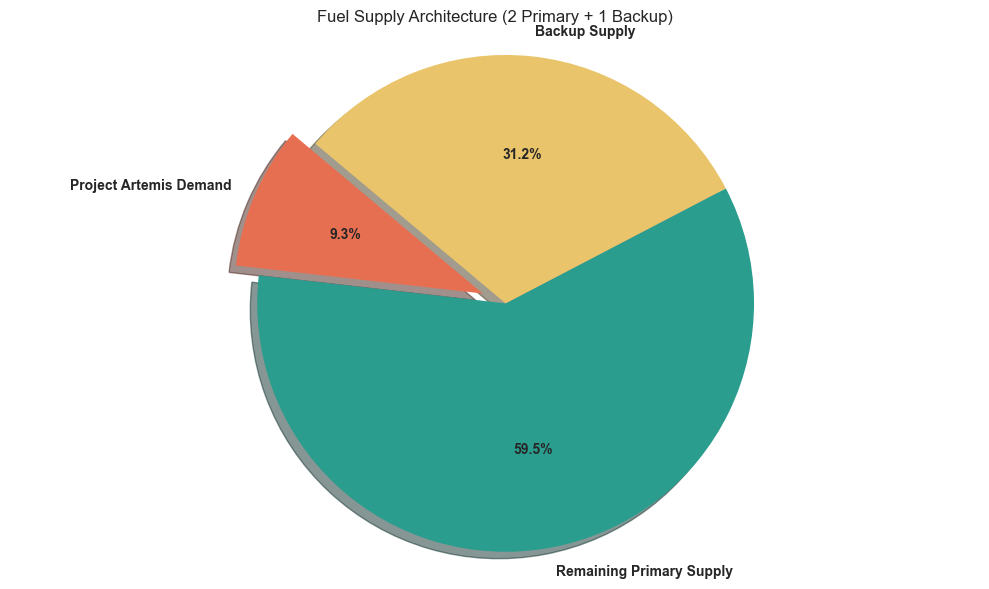

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

labels = ['Project Artemis Demand', 'Remaining Primary Supply', 'Backup Supply']
sizes = [0.031, 0.229 - 0.031, 0.104]
colors = ['#e76f51', '#2a9d8f', '#e9c46a']
explode = (0.1, 0, 0)  # explode 1st slice

fig, ax = plt.subplots(figsize=(10, 6))
ax.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=140, textprops={'fontweight': 'bold'})
ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
ax.set_title('Fuel Supply Architecture (2 Primary + 1 Backup)')

plt.tight_layout()
plt.show()

## SECTION 9: Conclusion and Forward Look

The engineering design solidly confirms the technical viability of Project Artemis. A robust, modular RICE-based power generation plant optimally utilizes the mildly cooled, lean associated gas stream. The base case uses a PUE of 1.40 and eight 3.3 MW engines for a 21.0 MW generation demand, with the CCP configuration treated as a quantified upside that can reduce facility load to approximately 17.45 MW.

The project consumes only a minor fraction (approximately 9.3%) of its primary supply, with backup capacity available, providing fuel security and unlocking significant carbon-mitigation potential.

**Next steps:**
The validated fuel consumption, equipment sizing, and CapEx markers established in this module feed directly into Notebook 5 (Supply Chain Logistics) and Notebook 7 (Financial Modeling and Investment Analysis).